<a href="https://colab.research.google.com/github/yoh6ly/Yohaly/blob/main/Clasificaci%C3%B3n_con_cegresi%C3%B3n_log%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

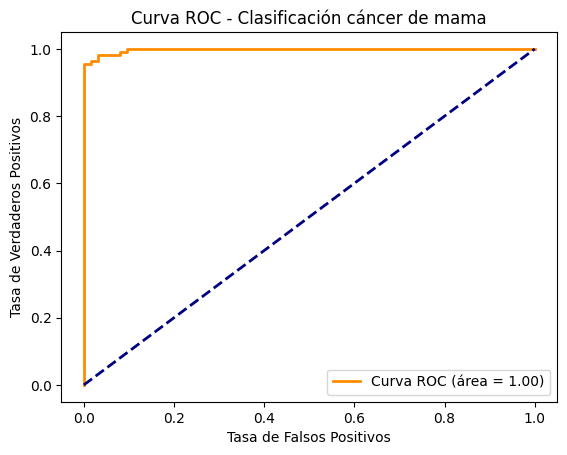

Precisión: 0.9814814814814815
Recall: 0.9814814814814815
F1-score: 0.9814814814814815
MSE: 0.023391812865497075

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        63
           1       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, mean_squared_error, classification_report

# Dataset real (cáncer de mama)
data = load_breast_cancer()
X, y = data.data, data.target

# Division en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenamiento de un modelo de clasificación
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)
y_score = model.predict_proba(X_test)[:, 1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='Curva ROC (área = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Clasificación cáncer de mama')
plt.legend(loc="lower right")
plt.show()

# Métricas de evaluación
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Precisión:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("MSE:", mse)

print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))